# Pl@ntNet comparison results

## Python library imports

In [4]:
import pandas as pd
import Common

## Derive plot data from result files

In [5]:
def calculate_result(label, file_prefix, filter_df=None):
    r = [ label ]
    for model in ['floralens','pn22','pn23','pn23_swe']:
        data = pd.read_csv(file_prefix  + model + '.tsv', sep='\t')
        if type(filter_df) == pd.DataFrame:
            data = data.merge(filter_df,on=['filename'])
        r.append(Common.mrr(data))
    return r
                     
 
floralens_dataset = pd.read_csv('../floralens/floralens_dataset.tsv', sep='\t')[['filename','repos']]

results = [
    calculate_result('FLTS', '../floralens/flts_'),
    calculate_result('FLTS-Pl@ntNet', '../floralens/flts_', 
                               floralens_dataset[floralens_dataset.repos != 'Pl@ntNet']),
    calculate_result('FLTS only Pl@ntNet', '../floralens/flts_', 
                               floralens_dataset[floralens_dataset.repos == 'Pl@ntNet']),
    calculate_result('PlantCLEF', '../plantclef/plantclef_'),
    calculate_result('Wikipedia', '../wikipedia/wikipedia_')
]
plot_data = pd.DataFrame(results, columns=['Dataset','Floralens','PN\'22','PN\'23','PN\'23-SWE'])
plot_data

,Dataset,Floralens,PN'22,PN'23,PN'23-SWE
0,FLTS,0.745110,0.675900,0.803663,0.800694
1,FLTS-Pl@ntNet,0.745615,0.626539,0.784040,0.777932
2,FLTS only Pl@ntNet,0.744167,0.767901,0.840236,0.843120
3,PlantCLEF,0.726385,0.720403,0.793223,0.792343
4,Wikipedia,0.724587,0.734209,0.784949,0.791759


## Derive plot 

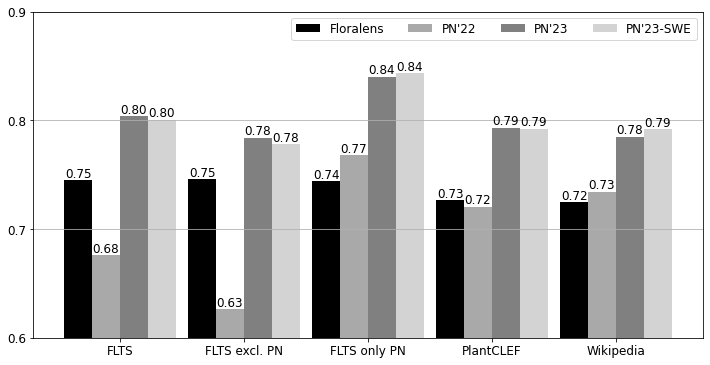

In [6]:
import matplotlib.ticker 
import matplotlib.pyplot as pyplt
font = {'family' : 'normal',
        'size'   : 12}

pyplt.rc('font', **font)
pyplt.rcParams["figure.figsize"] = (12,6)

plt = plot_data.plot.bar(x='Dataset',y=['Floralens','PN\'22', 'PN\'23','PN\'23-SWE'],
                         color=['black','darkgray','gray','lightgray'], width=0.9)
plt.set_ylim([0.6,0.9])
plt.legend(loc='upper right', ncol=4)
plt.set_xlabel('')
plt.set_yticks([0.60,0.70,0.80,0.90])
plt.grid(axis='y')
plt.set_xticklabels(['FLTS','FLTS excl. PN','FLTS only PN','PlantCLEF','Wikipedia'], rotation=0, ha='center')

#plt.invert_yaxis()

for container in plt.containers:
  plt.bar_label(container,fmt='%.2f')
#plt.get_figure().tight_layout()
plt.get_figure().savefig('plot_images/plantnet_comparison_results.pdf',bbox_inches='tight')